# Rolling PCA — Residuals and Signal Construction

This is the main residual/signal construction notebook. It runs the full pre-trading PCA residual pipeline:

1. **Rolling PCA** — extract $k$ common factors from an $L$-day window of standardised returns
2. **Regression residuals** — regress each stock's raw return on PCA factor returns and keep the residual $\varepsilon_{i,t}$ as the idiosyncratic component
3. **Rolling z-score** — standardise residuals over a prior $M$-day window using `.shift(1)` so no same-day data leaks into the signal
4. **Signal construction** — build threshold and quantile mean-reversion signals

**Main spec:** $L = 126$, $k = 10$, $M = 20$, threshold $c = 1.0$, quantile $q = 0.10$

**Timing rule:** at date $t$, all estimates must use only data through $t-1$. Positions open at $t$ and earn returns from $t \to t+1$.

Output files are tagged by spec using `OUTPUT_SUFFIX` (e.g. `_L126_K10_M20`) so that downstream notebooks can load the matching files.

In [1]:
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from tqdm import tqdm

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

PROCESSED = "../data/processed"
INTERIM   = "../data/interim"

# Main spec
L_MAIN         = 126   # PCA estimation window, roughly half a trading year
K_MAIN         = 10    # number of PCA factors retained
M_MAIN         = 20    # residual z-score lookback, roughly one trading month
THRESHOLD_MAIN = 1.0   # |z| threshold for entering a position
Q_MAIN         = 0.10  # quantile signal: long bottom Q, short top Q

OUTPUT_SUFFIX = f"_L{L_MAIN}_K{K_MAIN}_M{M_MAIN}"

In [2]:
log_returns = pd.read_parquet(f"{PROCESSED}/log_returns.parquet")

print(f"Shape : {log_returns.shape[0]} days × {log_returns.shape[1]} stocks")
print(f"Dates : {log_returns.index.min().date()}  →  {log_returns.index.max().date()}")
log_returns.iloc[:3, :5]

Shape : 3730 days × 200 stocks
Dates : 2011-06-27  →  2026-04-27


Ticker,TSLA,NVDA,AAPL,MSFT,AMZN
Date,,,,,
2011-06-27,-0.003998,-0.021189,0.017285,0.036368,0.044192
2011-06-28,0.023395,0.005823,0.009651,0.023530,0.005451
2011-06-29,0.006383,0.015365,-0.003646,-0.007001,0.009003


In [3]:
# --- Data quality diagnostics ---
bad_mask = ~np.isfinite(log_returns)
print("Total non-finite values:", bad_mask.sum().sum())

bad_by_col = bad_mask.sum().sort_values(ascending=False)
print(bad_by_col[bad_by_col > 0].head(20))

abs_ret = log_returns.abs()
print(abs_ret.stack().describe(percentiles=[0.99, 0.999, 0.9999]))

extreme = abs_ret > 0.5
print("Returns > 50% in absolute value:", extreme.sum().sum())
print(extreme.sum().sort_values(ascending=False).head(20))

Total non-finite values: 0
Series([], dtype: int64)
count     746000.000000
mean           0.012718
std            0.012617
min            0.000000
50%            0.008909
99%            0.059408
99.9%          0.084461
99.99%         0.105497
max            0.120467
dtype: float64
Returns > 50% in absolute value: 0
Ticker
TSLA    0
JCI     0
MPWR    0
GM      0
HCA     0
WELL    0
VLO     0
AMT     0
ICE     0
CSX     0
MO      0
AZO     0
PH      0
NVDA    0
MDLZ    0
MMM     0
FTNT    0
FDX     0
CB      0
MRSH    0
dtype: int64


In [4]:
# --- Cleaning: remove inf, mask insane returns, enforce static universe ---
log_returns = log_returns.replace([np.inf, -np.inf], np.nan)
log_returns = log_returns.mask(log_returns.abs() > 0.5)

min_obs = int(0.95 * len(log_returns))
good_cols = log_returns.columns[log_returns.notna().sum() >= min_obs]
log_returns = log_returns[good_cols].dropna()

print(f"After cleaning : {log_returns.shape[0]} days × {log_returns.shape[1]} stocks")
print(f"Dates          : {log_returns.index.min().date()}  →  {log_returns.index.max().date()}")
print(f"Remaining non-finite : {(~np.isfinite(log_returns)).sum().sum()}")

After cleaning : 3730 days × 200 stocks
Dates          : 2011-06-27  →  2026-04-27
Remaining non-finite : 0


### Rolling PCA + Regression Residuals

The model for each stock $i$ on day $\tau$ within the rolling window is:

$$r_{i,\tau} = \alpha_i + \beta_i^\top F_\tau + \varepsilon_{i,\tau}$$

where $F_\tau \in \mathbb{R}^k$ are PCA factor scores extracted from **standardised** returns (so they capture co-movement, not volatility magnitude), and the regression is on **raw** returns. This gives residuals $\varepsilon_{i,\tau}$ in raw return units, interpretable directly as unexplained daily P&L.

The regression is vectorised across all $N$ stocks in one `lstsq` call per window.

In [5]:
def rolling_pca_residuals(returns: pd.DataFrame, L: int, k: int, debug: bool = False):
    """
    Returns
    -------
    residuals        : DataFrame (T-L, N)   raw-return residuals from OLS
    evr              : DataFrame (T-L, k)   explained variance ratio per PC
    factor_returns   : DataFrame (T-L, k)   PCA factor scores for the last day of each window
    loadings_last    : ndarray  (k, N)      PC directions from the final window (for inspection)
    rolling_loadings : dict {date: DataFrame (N, k)}  per-date PC loading matrices
    """
    T, N    = returns.shape
    # Timing convention:
    # The PCA window R_vals[t-L:t] uses returns through date t-1.
    # We label the resulting residual with returns.index[t], the first date on which
    # the signal is tradable. Therefore dates = returns.index[L:] is intentional.
    # Downstream backtests should pair signal[t] with log_returns.shift(-1)[t].
    dates   = returns.index[L:]
    tickers = returns.columns

    resid_rows  = np.full((T - L, N), np.nan)
    evr_rows    = np.full((T - L, k), np.nan)
    factor_rows = np.full((T - L, k), np.nan)
    loadings_last    = None
    rolling_loadings = {}

    R_vals  = returns.values
    pc_cols = [f"PC{j+1}" for j in range(k)]

    for i, t in enumerate(tqdm(range(L, T), desc=f"L={L}, k={k}")):
        window = R_vals[t - L : t].copy()       # (L, N) raw returns

        if debug and not np.isfinite(window).all():
            raise ValueError(f"Non-finite values in window ending at {returns.index[t]}")

        # Standardise within window for PCA
        mu  = window.mean(axis=0)
        sig = window.std(axis=0, ddof=1)
        sig = np.where(sig == 0, 1.0, sig)
        R_std = (window - mu) / sig             # (L, N)

        # PCA on standardised returns → factor scores
        pca = PCA(n_components=k)
        F   = pca.fit_transform(R_std)          # (L, k)

        # OLS of raw returns on factor scores, vectorised over stocks
        F_aug = np.column_stack([np.ones(L), F])            # (L, k+1) with intercept
        coef, _, _, _ = np.linalg.lstsq(F_aug, window, rcond=None)  # (k+1, N)

        if debug and not np.isfinite(coef).all():
            raise ValueError(f"Non-finite OLS coefficients at {returns.index[t]}")

        resid = window - F_aug @ coef           # (L, N)

        resid_rows[i]  = resid[-1]              # residual for day t-1
        evr_rows[i]    = pca.explained_variance_ratio_
        factor_rows[i] = F[-1]                  # factor score for day t-1

        # Store loadings keyed by the first tradable date (same convention as residuals)
        signal_date = returns.index[t]
        rolling_loadings[signal_date] = pd.DataFrame(
            pca.components_.T,                  # (N, k)
            index=tickers,
            columns=pc_cols,
        )

        if i == T - L - 1:
            loadings_last = pca.components_     # (k, N)

    residuals      = pd.DataFrame(resid_rows,  index=dates, columns=tickers)
    evr            = pd.DataFrame(evr_rows,    index=dates, columns=pc_cols)
    factor_returns = pd.DataFrame(factor_rows, index=dates, columns=pc_cols)

    return residuals, evr, factor_returns, loadings_last, rolling_loadings

In [6]:
residuals, evr, factor_returns, loadings_last, rolling_loadings = rolling_pca_residuals(
    log_returns,
    L=L_MAIN,
    k=K_MAIN,
    debug=True,
)

print(f"Residuals        : {residuals.shape}")
print(f"EVR              : {evr.shape}")
print(f"Factor returns   : {factor_returns.shape}")
print(f"Rolling loadings : {len(rolling_loadings)} dates")
print(f"Date range       : {residuals.index.min().date()}  →  {residuals.index.max().date()}")

L=126, k=10:   0%|          | 0/3604 [00:00<?, ?it/s]/var/folders/w5/w5gx4xh14rn74jbyx12z69gh0000gn/T/ipykernel_99627/1286291430.py:52: RuntimeWarning: divide by zero encountered in matmul
  resid = window - F_aug @ coef           # (L, N)
/var/folders/w5/w5gx4xh14rn74jbyx12z69gh0000gn/T/ipykernel_99627/1286291430.py:52: RuntimeWarning: overflow encountered in matmul
  resid = window - F_aug @ coef           # (L, N)
/var/folders/w5/w5gx4xh14rn74jbyx12z69gh0000gn/T/ipykernel_99627/1286291430.py:52: RuntimeWarning: invalid value encountered in matmul
  resid = window - F_aug @ coef           # (L, N)
L=126, k=10:   0%|          | 1/3604 [00:00<20:01,  3.00it/s]/var/folders/w5/w5gx4xh14rn74jbyx12z69gh0000gn/T/ipykernel_99627/1286291430.py:52: RuntimeWarning: divide by zero encountered in matmul
  resid = window - F_aug @ coef           # (L, N)
/var/folders/w5/w5gx4xh14rn74jbyx12z69gh0000gn/T/ipykernel_99627/1286291430.py:52: RuntimeWarning: overflow encountered in matmul
  resid = windo

Residuals        : (3604, 200)
EVR              : (3604, 10)
Factor returns   : (3604, 10)
Rolling loadings : 3604 dates
Date range       : 2011-12-23  →  2026-04-27


In [19]:
# --- Acceptance checks ---
assert np.isfinite(residuals.values).all(),      "Non-finite values in residuals"
assert np.isfinite(evr.values).all(),            "Non-finite values in EVR"
assert np.isfinite(factor_returns.values).all(), "Non-finite values in factor returns"
print("All output assertions passed\n")

print("Residuals describe:")
print(residuals.stack().describe())


All output assertions passed

Residuals describe:
count    720800.000000
mean          0.000007
std           0.010808
min          -0.125540
25%          -0.005338
50%          -0.000039
75%           0.005294
max           0.131774
dtype: float64


The share of total return variation captured by the top $k$ components tells us how much of the cross-section is driven by common factors vs. idiosyncratic moves. Crisis periods typically show a spike — stocks become more correlated and PC1 dominates.

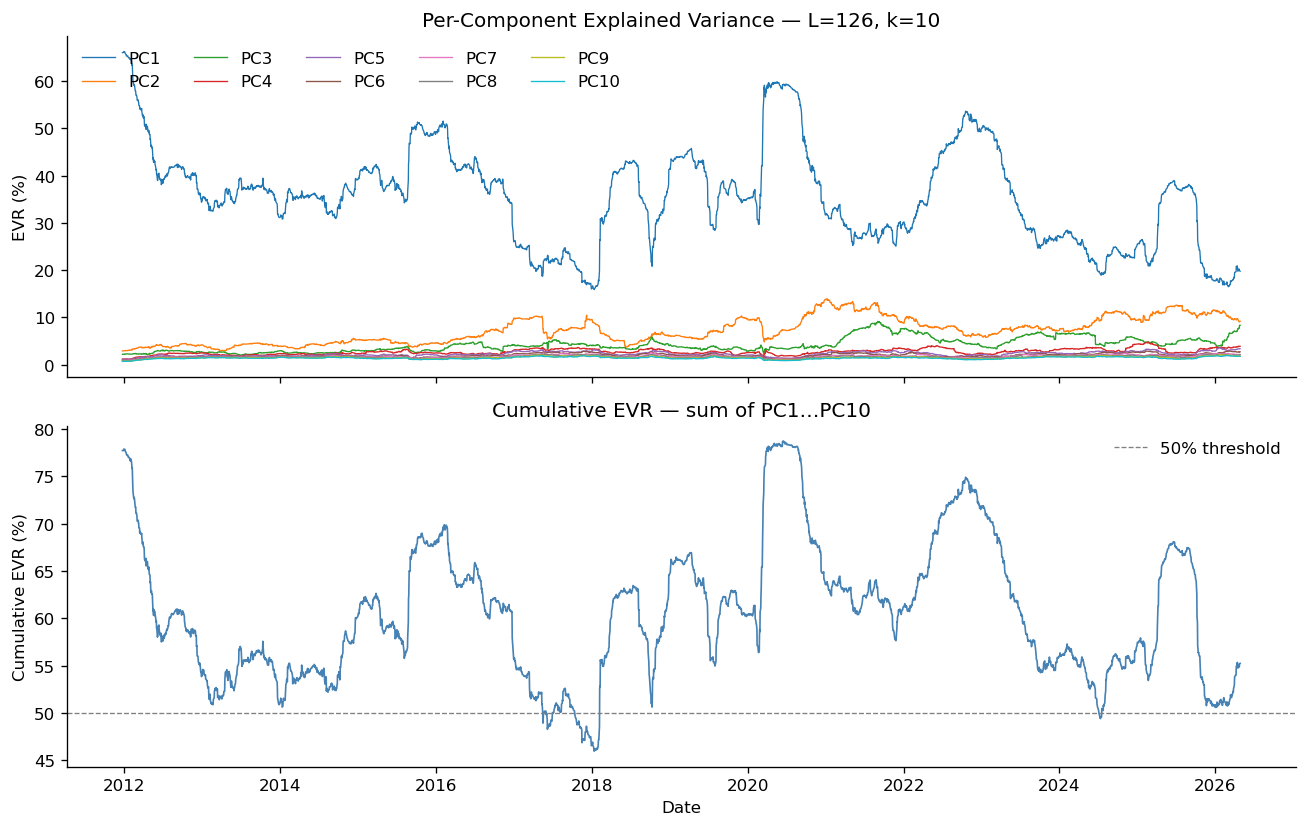

Mean cumulative EVR (PC1…PC10): 60.5%
Min : 46.0%
Max : 78.7%


In [8]:
cumulative_evr = evr.cumsum(axis=1)
evr_cum_through_k = cumulative_evr.iloc[:, -1]

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

ax = axes[0]
colors = plt.cm.tab10.colors
for j, col in enumerate(evr.columns):
    ax.plot(evr.index, evr[col] * 100, label=col, linewidth=0.8, color=colors[j % len(colors)])
ax.set_ylabel("EVR (%)")
ax.set_title(f"Per-Component Explained Variance — L={L_MAIN}, k={K_MAIN}")
ax.legend(frameon=False, ncol=5)

ax = axes[1]
ax.plot(evr_cum_through_k.index, evr_cum_through_k * 100, color="steelblue", linewidth=1)
ax.axhline(50, color="grey", linewidth=0.8, linestyle="--", label="50% threshold")
ax.set_ylabel("Cumulative EVR (%)")
ax.set_xlabel("Date")
ax.set_title(f"Cumulative EVR — sum of PC1…PC{K_MAIN}")
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

print(f"Mean cumulative EVR (PC1…PC{K_MAIN}): {evr_cum_through_k.mean():.1%}")
print(f"Min : {evr_cum_through_k.min():.1%}")
print(f"Max : {evr_cum_through_k.max():.1%}")

PC1 should show most stocks loading with the same sign — a broad market factor. Later PCs have mixed signs, reflecting sector or style tilts. These are statistical factors, not named economic factors.

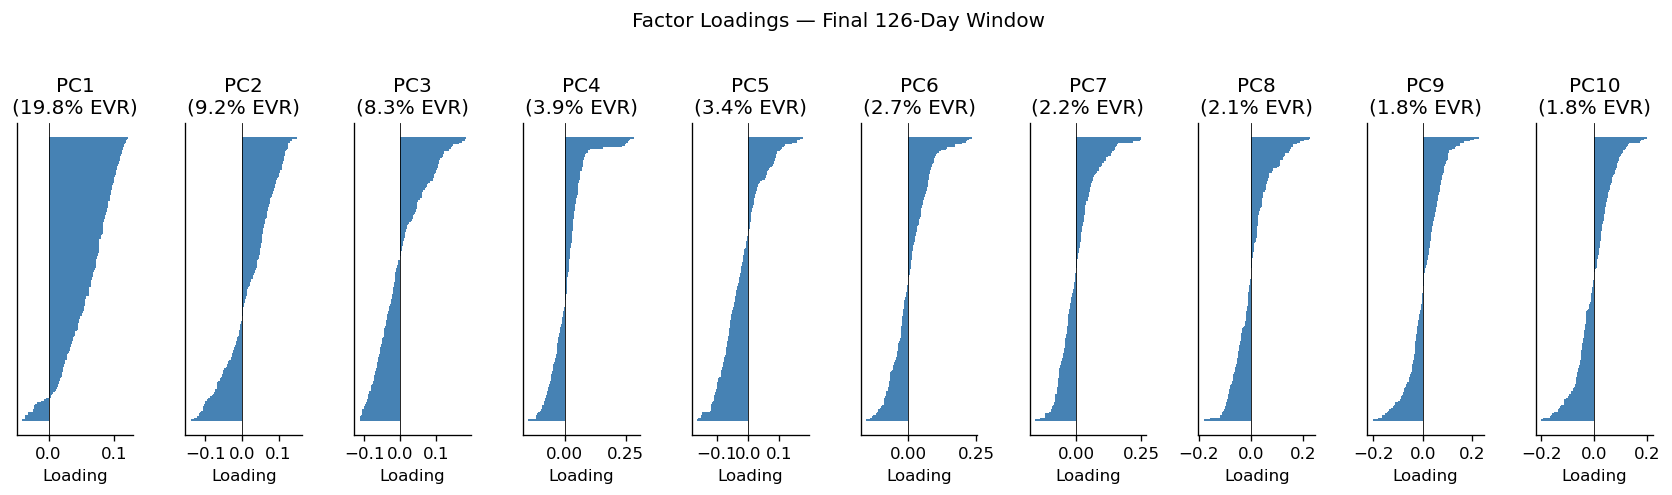

In [9]:
loadings_df = pd.DataFrame(
    loadings_last.T,
    index=log_returns.columns,
    columns=[f"PC{j+1}" for j in range(K_MAIN)],
)

fig, axes = plt.subplots(1, K_MAIN, figsize=(14, 4), sharey=False)
for j, ax in enumerate(axes):
    col = f"PC{j+1}"
    sorted_loads = loadings_df[col].sort_values()
    ax.barh(range(len(sorted_loads)), sorted_loads.values, color="steelblue", edgecolor="none", height=1.0)
    ax.axvline(0, color="black", linewidth=0.5)
    ax.set_yticks([])
    ax.set_xlabel("Loading")
    ax.set_title(f"{col}\n({evr[col].iloc[-1]:.1%} EVR)")

fig.suptitle(f"Factor Loadings — Final {L_MAIN}-Day Window", y=1.02)
plt.tight_layout()
plt.show()

Cumulative residuals for a few stocks should oscillate around zero — a visual check that the residual series has no persistent trend (which would indicate a missing factor or a broken implementation).

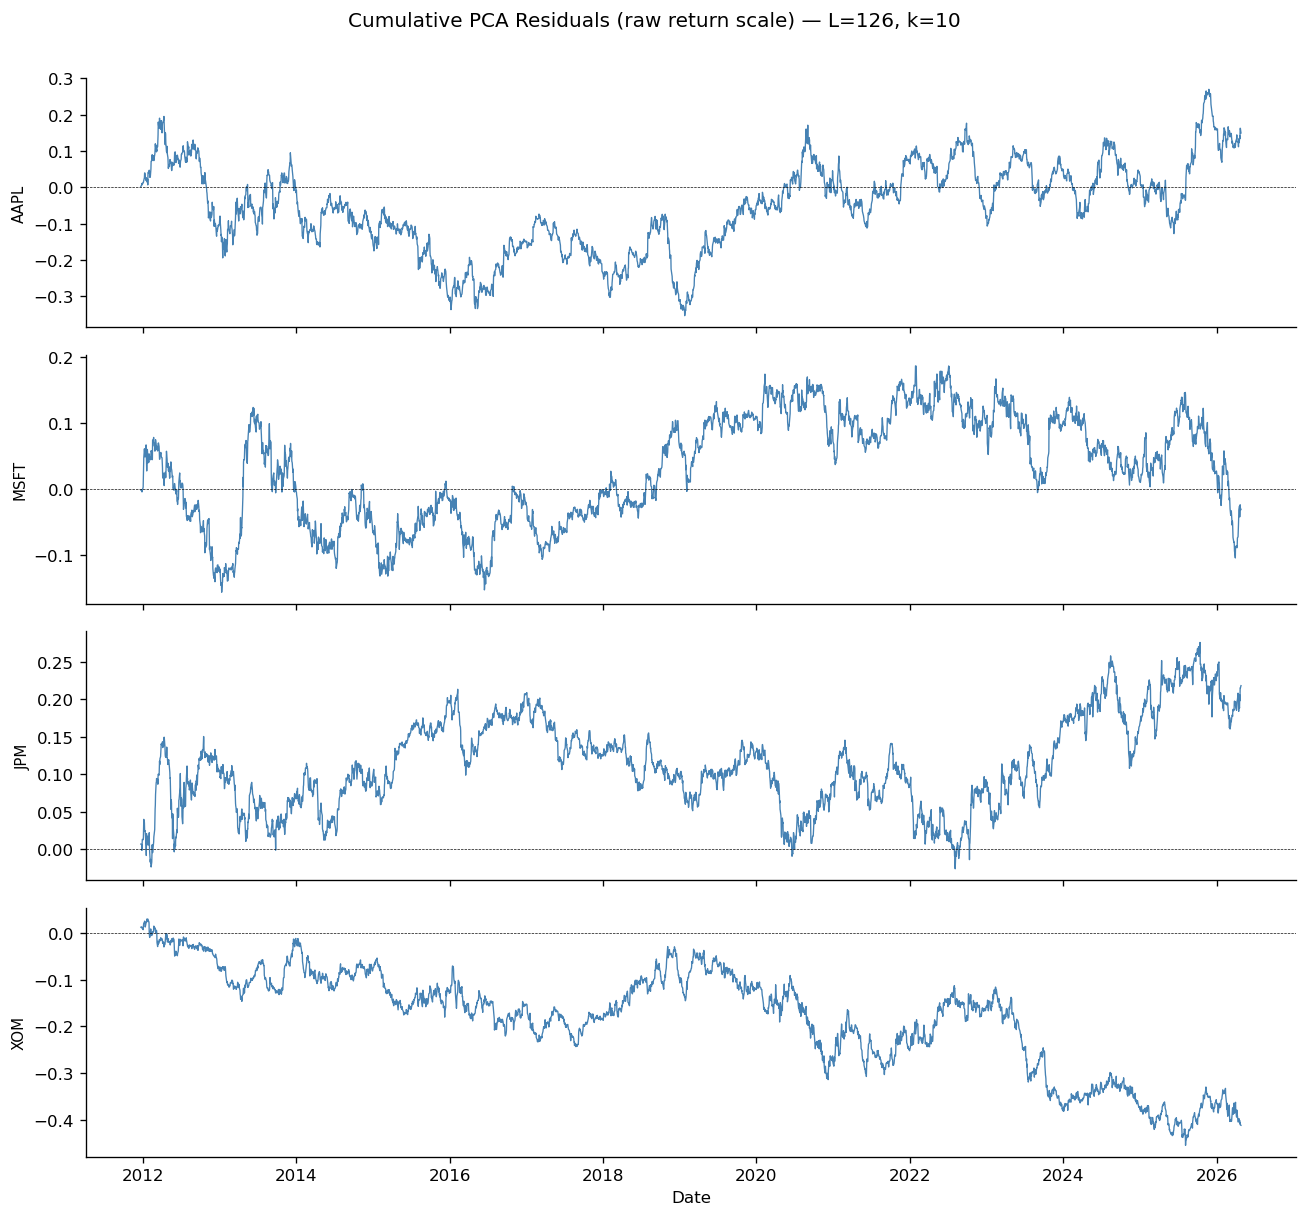

In [10]:
example_tickers = [t for t in ["AAPL", "MSFT", "JPM", "XOM"] if t in residuals.columns]

fig, axes = plt.subplots(len(example_tickers), 1, figsize=(11, 2.5 * len(example_tickers)), sharex=True)
if len(example_tickers) == 1:
    axes = [axes]

for ax, ticker in zip(axes, example_tickers):
    cumr = residuals[ticker].cumsum()
    ax.plot(cumr.index, cumr.values, linewidth=0.8, color="steelblue")
    ax.axhline(0, color="black", linewidth=0.4, linestyle="--")
    ax.set_ylabel(ticker, fontsize=9)

axes[-1].set_xlabel("Date")
fig.suptitle(f"Cumulative PCA Residuals (raw return scale) — L={L_MAIN}, k={K_MAIN}", y=1.01)
plt.tight_layout()
plt.show()

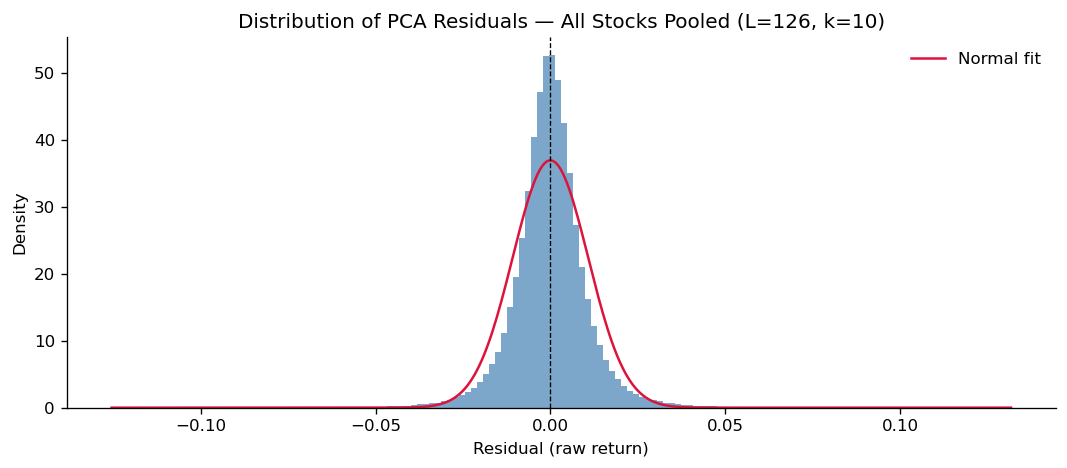

Mean : 0.000007  (should be ~0)
Std  : 0.010807


In [11]:
pooled_resid = residuals.values.flatten()
pooled_resid = pooled_resid[~np.isnan(pooled_resid)]

mu_r, sig_r = pooled_resid.mean(), pooled_resid.std()
x = np.linspace(pooled_resid.min(), pooled_resid.max(), 400)
normal_pdf = np.exp(-0.5 * ((x - mu_r) / sig_r) ** 2) / (sig_r * np.sqrt(2 * np.pi))

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(pooled_resid, bins=150, density=True, color="steelblue", alpha=0.7, edgecolor="none")
ax.plot(x, normal_pdf, color="crimson", linewidth=1.5, label="Normal fit")
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Residual (raw return)")
ax.set_ylabel("Density")
ax.set_title(f"Distribution of PCA Residuals — All Stocks Pooled (L={L_MAIN}, k={K_MAIN})")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

print(f"Mean : {mu_r:.6f}  (should be ~0)")
print(f"Std  : {sig_r:.6f}")

### Rolling Z-Score Construction

Raw residuals are not comparable across stocks — each has its own idiosyncratic volatility. We standardise each stock's residual series using its own rolling history:

$$z_{i,t} = \frac{\varepsilon_{i,t} - \mu_{i,t}^{(\varepsilon)}}{\sigma_{i,t}^{(\varepsilon)}}$$

where $\mu$ and $\sigma$ are computed over the prior $M$ residuals for stock $i$. The `.shift(1)` in the implementation ensures the z-score at date $t$ does not use the residual from date $t$ itself.

The first valid z-score date is approximately $L + M$ trading days into the sample.

In [12]:
# Because residuals are indexed by first tradable date, zscores[t] is also
# indexed by first tradable date. The shift(1) ensures the rolling mean/std
# use only residuals available before date t.
mu_e = residuals.rolling(M_MAIN).mean().shift(1)
sig_e = residuals.rolling(M_MAIN).std(ddof=1).shift(1)
zscores = (residuals - mu_e) / sig_e
zscores = zscores.dropna(how="all")

print(f"Z-scores : {zscores.shape[0]} days × {zscores.shape[1]} stocks")
print(f"Dates    : {zscores.index.min().date()}  →  {zscores.index.max().date()}")
print(f"\nFirst L+M={L_MAIN+M_MAIN} days consumed by estimation windows")

Z-scores : 3584 days × 200 stocks
Dates    : 2012-01-25  →  2026-04-27

First L+M=146 days consumed by estimation windows


In [13]:
print("Z-scores describe:")
print(zscores.stack().describe())

Z-scores describe:
count    716800.000000
mean         -0.000863
std           1.150254
min         -14.429677
25%          -0.641533
50%          -0.005785
75%           0.633408
max          14.259801
dtype: float64


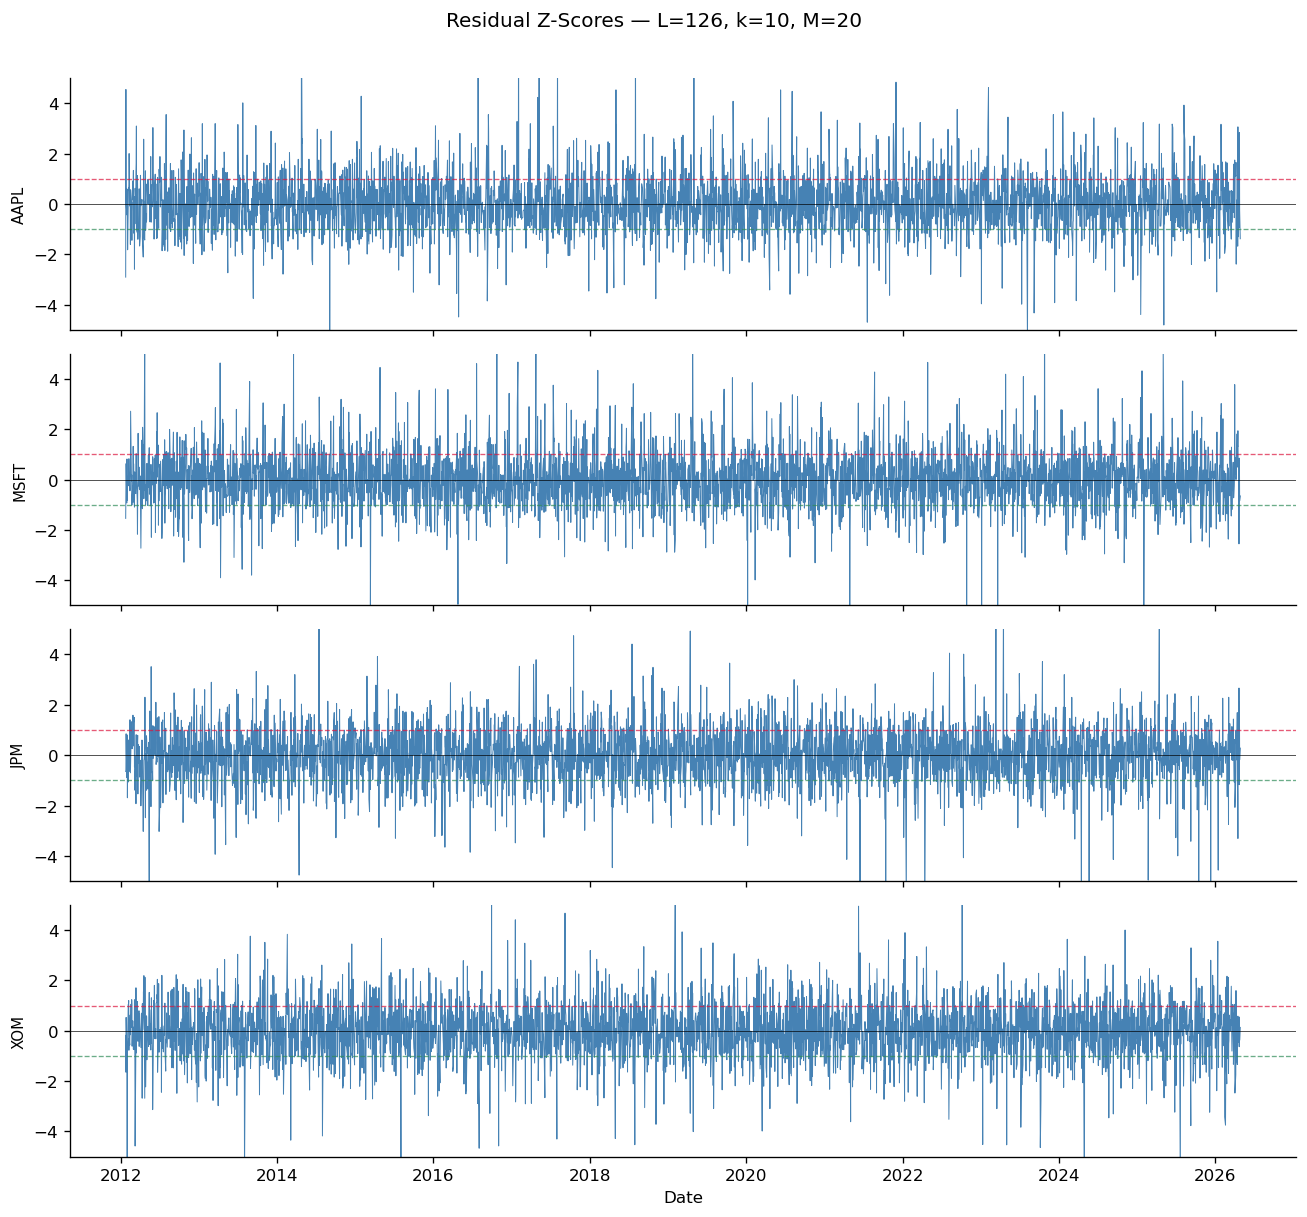

In [14]:
fig, axes = plt.subplots(len(example_tickers), 1, figsize=(11, 2.5 * len(example_tickers)), sharex=True)
if len(example_tickers) == 1:
    axes = [axes]

for ax, ticker in zip(axes, example_tickers):
    z = zscores[ticker]
    ax.plot(z.index, z.values, linewidth=0.6, color="steelblue")
    ax.axhline( 1.0, color="crimson",   linewidth=0.8, linestyle="--", alpha=0.7)
    ax.axhline(-1.0, color="seagreen",  linewidth=0.8, linestyle="--", alpha=0.7)
    ax.axhline( 0.0, color="black",     linewidth=0.4, linestyle="-")
    ax.set_ylabel(ticker, fontsize=9)
    ax.set_ylim(-5, 5)

axes[-1].set_xlabel("Date")
fig.suptitle(f"Residual Z-Scores — L={L_MAIN}, k={K_MAIN}, M={M_MAIN}", y=1.01)
plt.tight_layout()
plt.show()

### Signal Construction

#### Threshold Signal

Enter a position only when the z-score crosses a threshold $c$:

$$s_{i,t} = \begin{cases} +1 & z_{i,t} < -c \\ -1 & z_{i,t} > +c \\ 0 & |z_{i,t}| \leq c \end{cases}$$

Main spec: $c = 1.0$. Robustness grid: $c \in \{0.75, 1.0, 1.5, 2.0\}$.

#### Quantile Signal

Each day, rank all stocks by z-score. Long the bottom $q = 10\%$ (most oversold), short the top $q = 10\%$ (most overbought). This keeps the number of active positions stable regardless of volatility regime.

In [15]:
# Threshold signal — main spec (c = 1.0)
c = THRESHOLD_MAIN
signal_threshold = pd.DataFrame(0.0, index=zscores.index, columns=zscores.columns)
signal_threshold[zscores < -c] =  1.0   # long: stock underperformed → expect reversion up
signal_threshold[zscores >  c] = -1.0   # short: stock outperformed → expect reversion down

long_counts  = (signal_threshold ==  1).sum(axis=1)
short_counts = (signal_threshold == -1).sum(axis=1)

print(f"Threshold signal (c={c})")
print(f"  Avg longs  per day : {long_counts.mean():.1f}")
print(f"  Avg shorts per day : {short_counts.mean():.1f}")
print(f"  Avg total active   : {(long_counts + short_counts).mean():.1f} / {len(zscores.columns)} stocks")

Threshold signal (c=1.0)
  Avg longs  per day : 30.5
  Avg shorts per day : 30.6
  Avg total active   : 61.1 / 200 stocks


In [16]:
# Quantile signal (q = 0.10)
lo = zscores.quantile(Q_MAIN,       axis=1)   # per-date lower quantile
hi = zscores.quantile(1 - Q_MAIN,   axis=1)   # per-date upper quantile

signal_quantile = pd.DataFrame(0.0, index=zscores.index, columns=zscores.columns)
signal_quantile[zscores.le(lo, axis=0)]  =  1.0
signal_quantile[zscores.ge(hi, axis=0)]  = -1.0

long_q  = (signal_quantile ==  1).sum(axis=1)
short_q = (signal_quantile == -1).sum(axis=1)

print(f"Quantile signal (q={Q_MAIN})")
print(f"  Avg longs  per day : {long_q.mean():.1f}")
print(f"  Avg shorts per day : {short_q.mean():.1f}")

Quantile signal (q=0.1)
  Avg longs  per day : 20.0
  Avg shorts per day : 20.0


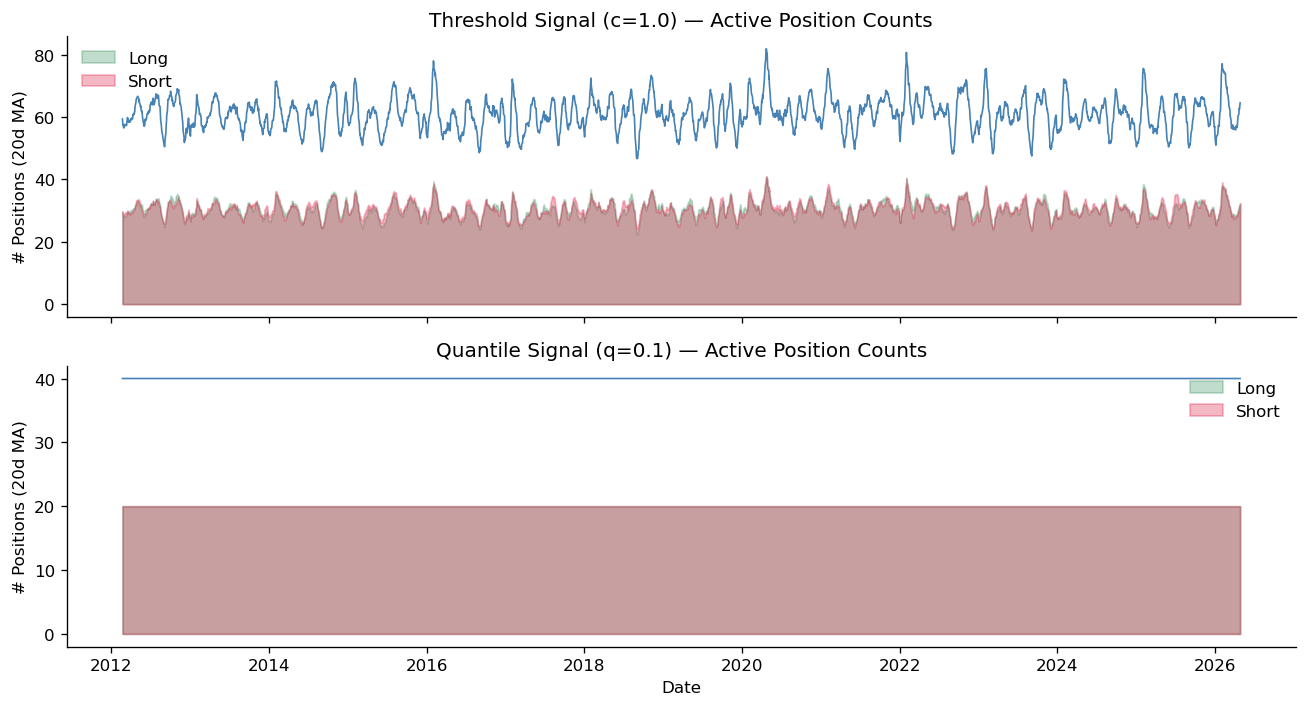

In [17]:
# Active position counts over time — threshold vs quantile
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

ax = axes[0]
total_thresh = long_counts + short_counts
ax.plot(total_thresh.index, total_thresh.rolling(20).mean(), color="steelblue", linewidth=1)
ax.fill_between(long_counts.index, 0, long_counts.rolling(20).mean(), alpha=0.3, color="seagreen", label="Long")
ax.fill_between(short_counts.index, 0, short_counts.rolling(20).mean(), alpha=0.3, color="crimson", label="Short")
ax.set_ylabel("# Positions (20d MA)")
ax.set_title(f"Threshold Signal (c={THRESHOLD_MAIN}) — Active Position Counts")
ax.legend(frameon=False)

ax = axes[1]
total_q = long_q + short_q
ax.plot(total_q.index, total_q.rolling(20).mean(), color="steelblue", linewidth=1)
ax.fill_between(long_q.index, 0, long_q.rolling(20).mean(), alpha=0.3, color="seagreen", label="Long")
ax.fill_between(short_q.index, 0, short_q.rolling(20).mean(), alpha=0.3, color="crimson", label="Short")
ax.set_ylabel("# Positions (20d MA)")
ax.set_xlabel("Date")
ax.set_title(f"Quantile Signal (q={Q_MAIN}) — Active Position Counts")
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

In [18]:
tag = OUTPUT_SUFFIX

residuals.to_parquet(       f"{PROCESSED}/residual_returns{tag}.parquet")
zscores.to_parquet(         f"{PROCESSED}/residual_zscores{tag}.parquet")
evr.to_parquet(             f"{PROCESSED}/pca_explained_variance{tag}.parquet")
factor_returns.to_parquet(  f"{PROCESSED}/pca_factor_returns{tag}.parquet")
signal_threshold.to_parquet(f"{PROCESSED}/signal_threshold_c{THRESHOLD_MAIN}{tag}.parquet")
signal_quantile.to_parquet( f"{PROCESSED}/signal_quantile_q{Q_MAIN}{tag}.parquet")

# Final-window loadings
loadings_payload = {
    "L": L_MAIN,
    "k": K_MAIN,
    "M": M_MAIN,
    "threshold": THRESHOLD_MAIN,
    "q": Q_MAIN,
    "loadings": loadings_last,                  # (k, N) ndarray
    "components": [f"PC{j+1}" for j in range(K_MAIN)],
    "tickers": list(log_returns.columns),
    "date": str(log_returns.index[-1].date()),
    "timing_convention": "indexed_by_first_tradable_date",
}
with open(f"{PROCESSED}/pca_loadings_final{tag}.pkl", "wb") as f:
    pickle.dump(loadings_payload, f)

# Rolling loadings by date
rolling_loadings_payload = {
    "L": L_MAIN,
    "k": K_MAIN,
    "M": M_MAIN,
    "loadings_by_date": rolling_loadings,       # {date: DataFrame (N, k)}
    "timing_convention": "indexed_by_first_tradable_date",
}
with open(f"{PROCESSED}/pca_rolling_loadings{tag}.pkl", "wb") as f:
    pickle.dump(rolling_loadings_payload, f)

print("Saved:")
print(f"  {PROCESSED}/residual_returns{tag}.parquet")
print(f"  {PROCESSED}/residual_zscores{tag}.parquet")
print(f"  {PROCESSED}/pca_explained_variance{tag}.parquet")
print(f"  {PROCESSED}/pca_factor_returns{tag}.parquet")
print(f"  {PROCESSED}/signal_threshold_c{THRESHOLD_MAIN}{tag}.parquet")
print(f"  {PROCESSED}/signal_quantile_q{Q_MAIN}{tag}.parquet")
print(f"  {PROCESSED}/pca_loadings_final{tag}.pkl")
print(f"  {PROCESSED}/pca_rolling_loadings{tag}.pkl")

print("\nMain PCA residual spec:")
print(f"  L_MAIN = {L_MAIN}")
print(f"  K_MAIN = {K_MAIN}")
print(f"  M_MAIN = {M_MAIN}")
print(f"  OUTPUT_SUFFIX = {OUTPUT_SUFFIX}")
print("  Timing convention: indexed by first tradable date")
print("  Backtest convention: weights[t] × log_returns.shift(-1)[t]")

Saved:
  ../data/processed/residual_returns_L126_K10_M20.parquet
  ../data/processed/residual_zscores_L126_K10_M20.parquet
  ../data/processed/pca_explained_variance_L126_K10_M20.parquet
  ../data/processed/pca_factor_returns_L126_K10_M20.parquet
  ../data/processed/signal_threshold_c1.0_L126_K10_M20.parquet
  ../data/processed/signal_quantile_q0.1_L126_K10_M20.parquet
  ../data/processed/pca_loadings_final_L126_K10_M20.pkl
  ../data/processed/pca_rolling_loadings_L126_K10_M20.pkl

Main PCA residual spec:
  L_MAIN = 126
  K_MAIN = 10
  M_MAIN = 20
  OUTPUT_SUFFIX = _L126_K10_M20
  Timing convention: indexed by first tradable date
  Backtest convention: weights[t] × log_returns.shift(-1)[t]
